# 06 — Alternative Models

**Pipeline stage 6 of 7.** Five competing modeling approaches whose probability
streams will be compared against the LSTM baseline in notebook 07.

- **Part 22** — VAR (vector autoregression) baseline
- **Part 23** — Regime-switching dual LSTM (HMM + bloom/dormant specialists)
- **Part 24** — Physics-informed LSTM (advection-diffusion loss)
- **Part 25** — Gaussian Process residual layer on top of the LSTM
- **Part 26** — Hybrid ensemble (LSTM + ARIMA + Kalman, performance-weighted)

Each section is independent of the others; they all consume the trained baseline
LSTM and the test sequences/probabilities. You can run them in any order.

**Inputs**
- Trained baseline model + test probabilities (notebook 03)
- Sequences and unscaled splits (notebook 01)

**Outputs**
- `alt_model_streams.npz` — per-model probability streams on the test set,
  consumed by notebook 07 for the final comparison table and significance tests

> Source: Parts 22–26 of the original monolithic notebook.


## Setup

In [1]:
!pip install -q statsmodels hmmlearn pmdarima


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import numpy as np
import pandas as pd
import joblib

from tensorflow.keras.models import Model, load_model

from shared_config import *
print_config_summary()


--- Workflow Configuration Summary ---
Enhanced Features Enabled:     True
Scaler Type Selected:          Robust
Class Weighting Enabled:       True
Hyperparameter Tuning Enabled: True
EnKF Enabled:                  True
FAST_TEST Mode:                False
Sequence Length (default):     26
Forecast Horizon:              1 week(s)
Output directory:              output_refactored/
--------------------------------------


## Load upstream artifacts

In [3]:
from lstm_utils import (create_sequences_from_df, build_tunable_lstm,
                        class_weights_powered)
from pipeline_utils import load_hps, load_sequence_artifact, write_json

try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

raw_seq = load_sequence_artifact(RAW_TUNED_SEQUENCES_PATH if os.path.exists(RAW_TUNED_SEQUENCES_PATH) else RAW_SEQUENCES_PATH)
X_train = raw_seq["X_train"]; y_train = raw_seq["y_train"]
X_val = raw_seq["X_val"]; y_val = raw_seq["y_val"]
X_test = raw_seq["X_test"]; y_test = raw_seq["y_test"]
feature_columns = raw_seq["feature_columns"]
SEQUENCE_LENGTH = raw_seq["seq_length"]

train_df_unscaled = pd.read_parquet(TRAIN_DF_PATH)
val_df_unscaled = pd.read_parquet(VAL_DF_PATH)
test_df_unscaled = pd.read_parquet(TEST_DF_PATH)
train_df, validation_df, test_df = train_df_unscaled, val_df_unscaled, test_df_unscaled

train_scaled_df = pd.read_parquet(TRAIN_SCALED_PATH)
validation_scaled_df = pd.read_parquet(VAL_SCALED_PATH)
test_scaled_df = pd.read_parquet(TEST_SCALED_PATH)
scaler = joblib.load(SCALER_FILENAME)
final_feature_columns_used = joblib.load(FEATURE_LIST_FILENAME)

raw_hps_dict = load_hps(RAW_BEST_HPS_PATH if os.path.exists(RAW_BEST_HPS_PATH) else BEST_HPS_PATH, DEFAULT_HPS_DICT)

if not os.path.exists(STANDALONE_LSTM_MODEL_PATH):
    raise FileNotFoundError(f"Missing {STANDALONE_LSTM_MODEL_PATH}; run notebook 03 first.")
model = load_model(STANDALONE_LSTM_MODEL_PATH, compile=False)
trained_model = model

lstm_p_test = np.load(LSTM_TEST_PROBS_PATH)
lstm_enkf_p_test = np.load(LSTM_ENKF_TEST_PROBS_PATH) if os.path.exists(LSTM_ENKF_TEST_PROBS_PATH) else None
mc_preds = np.load(MC_PREDS_PATH) if os.path.exists(MC_PREDS_PATH) else None
y_eval_full = np.asarray(y_test).flatten().astype(int)
n_eval = len(y_eval_full)
alt_tuning_summary = {}

print(f"X_train {X_train.shape}, X_test {X_test.shape}, y_test {y_test.shape}")
print(f"trained_model loaded from {STANDALONE_LSTM_MODEL_PATH}")
print(f"lstm_p_test {lstm_p_test.shape}; lstm_enkf_p_test {None if lstm_enkf_p_test is None else lstm_enkf_p_test.shape}")


X_train (1097, 26, 26), X_test (216, 26, 26), y_test (216,)
trained_model loaded from output_refactored/best_lstm_model_standalone_lstm_tuned_weighted.keras
lstm_p_test (216,); lstm_enkf_p_test (216,)


## Part 22: VAR Baseline

A Vector Autoregression treats all environmental drivers + `kb` as a coupled linear system. It's cheap, interpretable, and a strong baseline. If your LSTM doesn't clearly beat VAR, the nonlinear capacity isn't paying off.

**Setup**
- State vector: `[kb, peace_discharge, peace_TN, peace_TP, water_temp, wind_u, wind_v, zos]` (log1p-transformed for kb)
- Lag order chosen by AIC up to 12 weeks
- Forecasts produced recursively for the test set
- Binary bloom forecast = (forecast_kb >= BLOOM_THRESHOLD)


In [4]:
# --- Part 22: VAR baseline ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, brier_score_loss, f1_score, average_precision_score

try:
    from statsmodels.tsa.api import VAR
except ImportError:
    !pip install statsmodels -q
    from statsmodels.tsa.api import VAR


VAR_FEATURES = [c for c in [
    'kb', 'peace_discharge', 'peace_TN', 'peace_TP',
    'water_temp', 'wind_u', 'wind_v', 'zos'
] if c in train_df.columns]
print(f"VAR features available: {VAR_FEATURES}")

# We work on log1p(kb) so multiplicative bloom dynamics are linearised.
def _prep_var_frame(df, cols):
    out = df[cols].copy().astype(float)
    if 'kb' in out.columns:
        out['kb'] = np.log1p(np.clip(out['kb'].values, 0, None))
    return out.dropna()

var_train = _prep_var_frame(train_df, VAR_FEATURES)
var_val   = _prep_var_frame(validation_df,   VAR_FEATURES)
var_test  = _prep_var_frame(test_df,  VAR_FEATURES)
print(f"VAR shapes  train={var_train.shape}  val={var_val.shape}  test={var_test.shape}")

# Fit on train + val (more data; chronological so no leakage into test)
fit_df = pd.concat([var_train, var_val], axis=0)
var_model = VAR(fit_df)
order_results = var_model.select_order(maxlags=min(12, len(fit_df)//5))
best_lag = max(1, order_results.aic if isinstance(order_results.aic, int) else 1)
print(f"AIC-selected VAR order: {best_lag}")
var_fit = var_model.fit(best_lag)

# Rolling 1-step-ahead forecasts on test
log_threshold = np.log1p(BLOOM_THRESHOLD)
kb_idx = VAR_FEATURES.index('kb')
history = fit_df.values.copy()
var_kb_logforecasts = []

for i in range(len(var_test)):
    fcast = var_fit.forecast(history[-best_lag:], steps=1)[0]
    var_kb_logforecasts.append(fcast[kb_idx])
    # append actual observed row (true assimilation -- mirrors how EnKF uses obs)
    history = np.vstack([history, var_test.iloc[i].values])

var_kb_logforecasts = np.array(var_kb_logforecasts)
# Probabilistic interpretation: residual std as Gaussian → P(kb >= threshold)
resid_std = np.std(var_fit.resid.iloc[:, kb_idx].values)
from scipy.stats import norm
var_bloom_prob = 1.0 - norm.cdf(log_threshold, loc=var_kb_logforecasts, scale=resid_std)

# Align to y_test length (y_test may be shorter due to sequence windowing)
n_eval = min(len(y_test), len(var_bloom_prob))
y_eval = np.asarray(y_test).flatten()[-n_eval:]
var_prob_eval = var_bloom_prob[-n_eval:]

var_metrics = {
    'AUC':     roc_auc_score(y_eval, var_prob_eval) if len(np.unique(y_eval)) > 1 else np.nan,
    'AUPRC':   average_precision_score(y_eval, var_prob_eval),
    'Brier':   brier_score_loss(y_eval, var_prob_eval),
    'F1@0.5':  f1_score(y_eval, (var_prob_eval >= 0.5).astype(int), zero_division=0),
}
print(f"\n--- VAR(p={best_lag}) baseline ---")
for k, v in var_metrics.items():
    print(f"  {k}: {v:.4f}")


VAR features available: ['kb', 'peace_discharge', 'peace_TN', 'peace_TP', 'water_temp', 'wind_u', 'wind_v', 'zos']
VAR shapes  train=(1123, 8)  val=(240, 8)  test=(242, 8)
AIC-selected VAR order: 1

--- VAR(p=1) baseline ---
  AUC: 0.9692
  AUPRC: 0.9282
  Brier: 0.1031
  F1@0.5: 0.6667


C:\Users\victo\PycharmProjects\ENKF\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)


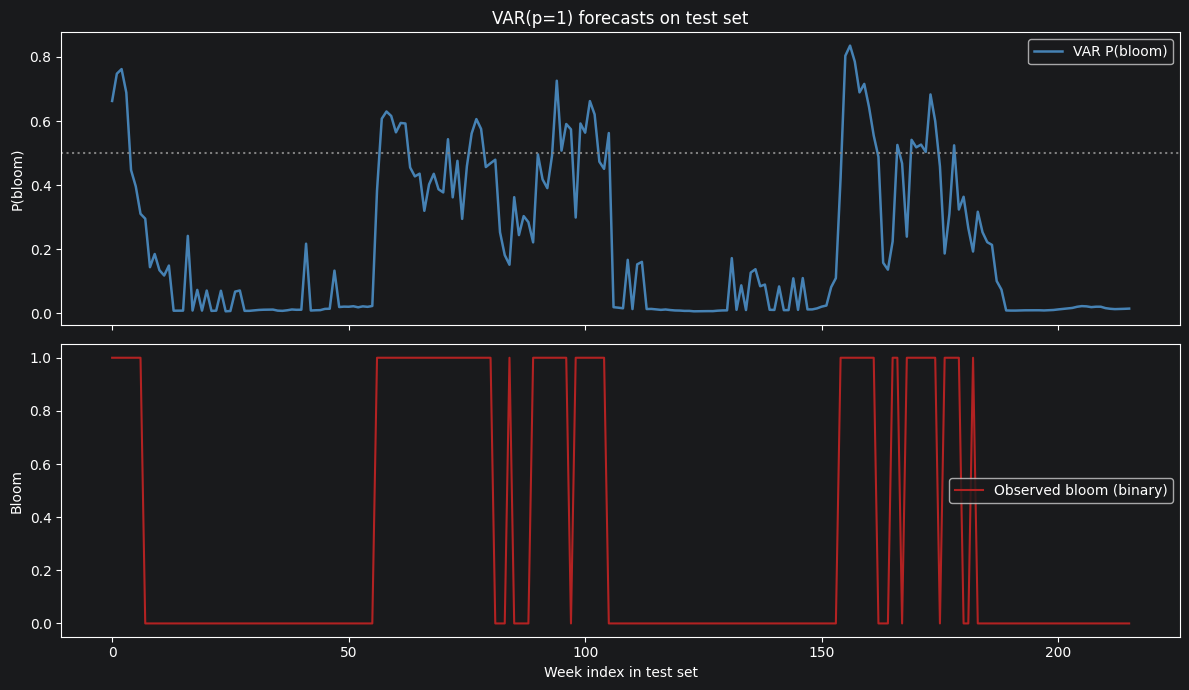

In [5]:
# --- Visualize VAR forecasts vs ground truth ---
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
t = np.arange(len(var_prob_eval))
ax[0].plot(t, var_prob_eval, color='steelblue', lw=1.8, label='VAR P(bloom)')
ax[0].axhline(0.5, ls=':', color='gray')
ax[0].set_ylabel('P(bloom)')
ax[0].set_title(f'VAR(p={best_lag}) forecasts on test set')
ax[0].legend()
ax[1].plot(t, y_eval, color='firebrick', lw=1.5, label='Observed bloom (binary)')
ax[1].set_ylabel('Bloom')
ax[1].set_xlabel('Week index in test set')
ax[1].legend()
plt.tight_layout()
plt.savefig('output_refactored/var_baseline_forecasts.png', dpi=200, bbox_inches='tight')
plt.show()


## Part 23: Regime-Switching (Dormant vs. Blooming)

We fit a 2-state Gaussian HMM to historical log-kb so each timestep gets a soft regime label (dormant / active). Then we train **two specialist LSTMs**: one on dormant-regime windows, one on blooming-regime windows. At inference we blend their predictions by current regime posterior probability.

**Why this might help:** *Karenia brevis* dynamics differ between dormant baseline and blooming periods (different growth rates, nutrient sensitivities, advection effects). A single LSTM averages over both, potentially losing skill on transitions.

**Why it might NOT help:** Dataset gets split, so each specialist sees less data; if bloom periods are sparse the bloom-LSTM is data-starved.


HMM state means: [ 0.         10.77412706]
-> bloom state = 1, dormant state = 0


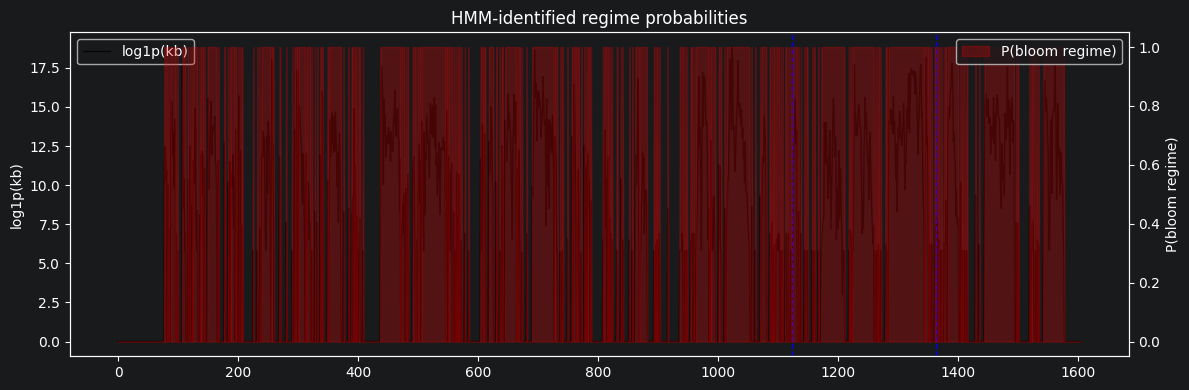

In [6]:
# --- Part 23: Regime detection via HMM ---
try:
    from hmmlearn.hmm import GaussianHMM
except ImportError:
    !pip install hmmlearn -q
    from hmmlearn.hmm import GaussianHMM

# Feature for regime detection: log1p kb (could also include env vars; keeping it interpretable)
def _kb_signal(df):
    s = np.log1p(np.clip(df[TARGET_COL].astype(float).values, 0, None)).reshape(-1, 1)
    return s

sig_train = _kb_signal(train_df)
sig_val   = _kb_signal(validation_df)
sig_test  = _kb_signal(test_df)

np.random.seed(42)
hmm = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=42)
hmm.fit(sig_train)

# Identify which hidden state corresponds to "blooming" (higher mean)
means = hmm.means_.flatten()
bloom_state = int(np.argmax(means))
dormant_state = 1 - bloom_state
print(f"HMM state means: {means}")
print(f"-> bloom state = {bloom_state}, dormant state = {dormant_state}")

# Posterior regime probabilities for every split
post_train = hmm.predict_proba(sig_train)[:, bloom_state]
post_val   = hmm.predict_proba(sig_val)[:, bloom_state]
post_test  = hmm.predict_proba(sig_test)[:, bloom_state]

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
combined_kb = np.concatenate([sig_train.flatten(), sig_val.flatten(), sig_test.flatten()])
combined_post = np.concatenate([post_train, post_val, post_test])
ax.plot(combined_kb, color='black', lw=1, alpha=0.7, label='log1p(kb)')
ax2 = ax.twinx()
ax2.fill_between(np.arange(len(combined_post)), 0, combined_post, color='red', alpha=0.25, label='P(bloom regime)')
ax.axvline(len(sig_train), ls='--', color='blue', lw=1)
ax.axvline(len(sig_train)+len(sig_val), ls='--', color='blue', lw=1)
ax.set_ylabel('log1p(kb)')
ax2.set_ylabel('P(bloom regime)')
ax.set_title('HMM-identified regime probabilities')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.savefig('output_refactored/regime_probs.png', dpi=200); plt.show()


In [7]:
# --- Part 23 (cont'd): Build & train two specialist LSTMs ---
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy
from sklearn.utils.class_weight import compute_class_weight

# X_train has shape (N, seq_len, n_features). We need a regime label per sequence
# = the regime at the LAST timestep of the input window (i.e., "the regime entering forecast")
def _seq_regime_labels(post_probs, n_sequences, seq_len):
    # last timestep index of each sequence in the original df
    last_idx = np.arange(seq_len - 1, seq_len - 1 + n_sequences)
    last_idx = np.clip(last_idx, 0, len(post_probs)-1)
    return post_probs[last_idx]

seq_regime_train = _seq_regime_labels(post_train, len(X_train), SEQUENCE_LENGTH)
seq_regime_val   = _seq_regime_labels(post_val,   len(X_val),   SEQUENCE_LENGTH)
seq_regime_test  = _seq_regime_labels(post_test,  len(X_test),  SEQUENCE_LENGTH)

# Sample weights: bloom-LSTM weights examples by P(bloom regime), dormant-LSTM by (1 - P)
sw_bloom_train   = seq_regime_train + 1e-3
sw_dormant_train = (1.0 - seq_regime_train) + 1e-3

def build_specialist(input_shape, name):
    hps = dict(DEFAULT_HPS_DICT)
    hps.update(raw_hps_dict)
    inp = Input(shape=input_shape, name=f'{name}_input')
    x = inp
    layer_sizes = [hps['units_1'], hps['units_2'], hps.get('units_3', 16)]
    for i in range(int(hps['n_lstm_layers'])):
        return_seq = i < int(hps['n_lstm_layers']) - 1
        x = LSTM(layer_sizes[i], return_sequences=return_seq)(x)
        x = Dropout(hps['dropout'])(x)
    out = Dense(1, activation='sigmoid', name=f'{name}_out')(x)
    m = Model(inp, out, name=f'lstm_{name}')
    m.compile(optimizer=Adam(hps['learning_rate']), loss=BinaryCrossentropy(),
              metrics=[BinaryAccuracy(name='acc'), AUC(name='auc')])
    return m

input_shape = (X_train.shape[1], X_train.shape[2])
lstm_bloom   = build_specialist(input_shape, 'bloom')
lstm_dormant = build_specialist(input_shape, 'dormant')

# Class weights (still imbalanced within each regime)
cw = compute_class_weight('balanced',
                          classes=np.unique(y_train.flatten()),
                          y=y_train.flatten().astype(int))
cw_dict = {int(c): float(w) for c, w in zip(np.unique(y_train.flatten()), cw)}

# Fold class weights INTO sample weights — Keras forbids passing both,
# so multiply per-example regime weight by per-example class weight.
y_train_flat = y_train.flatten().astype(int)
cw_per_sample = np.array([cw_dict[int(y)] for y in y_train_flat], dtype=np.float32)

sw_bloom_train_eff   = sw_bloom_train   * cw_per_sample
sw_dormant_train_eff = sw_dormant_train * cw_per_sample

es = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=TRAIN_PATIENCE, restore_best_weights=True)

print('Training bloom specialist...')
lstm_bloom.fit(X_train, y_train, validation_data=(X_val, y_val),
               sample_weight=sw_bloom_train_eff, epochs=TRAIN_EPOCHS, batch_size=raw_hps_dict['batch_size'],
               callbacks=[es], verbose=0)

print('Training dormant specialist...')
lstm_dormant.fit(X_train, y_train, validation_data=(X_val, y_val),
                 sample_weight=sw_dormant_train_eff, epochs=TRAIN_EPOCHS, batch_size=raw_hps_dict['batch_size'],
                 callbacks=[es], verbose=0)

# Regime-blended predictions on test set
p_bloom_specialist   = lstm_bloom.predict(X_test, verbose=0).flatten()
p_dormant_specialist = lstm_dormant.predict(X_test, verbose=0).flatten()
w_bloom_test = seq_regime_test
p_regime_blend = w_bloom_test * p_bloom_specialist + (1 - w_bloom_test) * p_dormant_specialist

y_eval_full = np.asarray(y_test).flatten()
regime_metrics = {
    'AUC':    roc_auc_score(y_eval_full, p_regime_blend) if len(np.unique(y_eval_full)) > 1 else np.nan,
    'AUPRC':  average_precision_score(y_eval_full, p_regime_blend),
    'Brier':  brier_score_loss(y_eval_full, p_regime_blend),
    'F1@0.5': f1_score(y_eval_full, (p_regime_blend >= 0.5).astype(int), zero_division=0),
}
print('\n--- Regime-switching dual-LSTM ---')
for k, v in regime_metrics.items():
    print(f'  {k}: {v:.4f}')

alt_tuning_summary["regime_specialists"] = {
    "architecture_source": "standalone_lstm_best_hps",
    "epochs": TRAIN_EPOCHS,
    "batch_size": int(raw_hps_dict['batch_size']),
    "patience": TRAIN_PATIENCE,
}


Training bloom specialist...
Training dormant specialist...

--- Regime-switching dual-LSTM ---
  AUC: 0.9562
  AUPRC: 0.9130
  Brier: 0.1128
  F1@0.5: 0.8553


## Part 24: PINN — Advection-Diffusion Physics Loss

We embed a **simplified advection-diffusion-reaction** equation as a soft constraint on the LSTM. At a point location, *K. brevis* concentration evolves as:

$$\frac{\partial C}{\partial t} = \underbrace{-\mathbf{u}\cdot\nabla C}_{\text{advection}} + \underbrace{D\nabla^2 C}_{\text{diffusion}} + \underbrace{\mu(N,T)\,C - mC}_{\text{growth - mortality}}$$

We can't compute spatial gradients from a single time series, so we approximate with a **local conservation form**:

$$\Delta C_t \approx \alpha \cdot N_t \cdot C_{t-1} - \beta \cdot C_{t-1} - \gamma \cdot \|\mathbf{u}_t\| \cdot C_{t-1}$$

The LSTM has a **dual head**: (a) binary bloom probability, and (b) a continuous next-step log-kb estimate. The physics loss penalises the continuous head when it violates the local balance. Wind magnitude proxies advection-out, nutrients (TN, TP) drive growth, a learned decay term handles mortality.

**Loss** = BCE(bloom_prob, y) + α · MSE(log_kb_pred, log_kb_true) + λ · physics_residual²


In [8]:
# --- Part 24: Build PINN-style LSTM with dual head ---
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Find feature indices we'll need for physics residual
def _find_idx(colname):
    return final_feature_columns_used.index(colname) if colname in final_feature_columns_used else None

idx_kb       = _find_idx('kb')           # current kb in window (unscaled later)
idx_kb_L1    = _find_idx('kb_L1')        # 1-step lag of kb (if engineered)
idx_TN       = _find_idx('peace_TN')
idx_TP       = _find_idx('peace_TP')
idx_wind_u   = _find_idx('wind_u')
idx_wind_v   = _find_idx('wind_v')
idx_T        = _find_idx('water_temp')
print(f'Feature indices: kb={idx_kb}, kb_L1={idx_kb_L1}, TN={idx_TN}, TP={idx_TP}, '
      f'wind_u={idx_wind_u}, wind_v={idx_wind_v}, T={idx_T}')

# Compute true continuous kb target (next-step log1p kb) for each training sample
# We assume y_train was created from the (next-step) kb. We need the actual numeric next-step kb.
def _continuous_kb_target(df, seq_len, n_seq):
    kb_series = np.log1p(np.clip(df[TARGET_COL].astype(float).values, 0, None))
    # target for sequence i is kb at index (seq_len - 1 + i + 1) = seq_len + i
    targets = []
    for i in range(n_seq):
        t = seq_len + i
        if t < len(kb_series):
            targets.append(kb_series[t])
        else:
            targets.append(kb_series[-1])
    return np.array(targets, dtype=np.float32)

logkb_train = _continuous_kb_target(train_df, SEQUENCE_LENGTH, len(X_train))
logkb_val   = _continuous_kb_target(validation_df,   SEQUENCE_LENGTH, len(X_val))
logkb_test  = _continuous_kb_target(test_df,  SEQUENCE_LENGTH, len(X_test))

def build_pinn_lstm(input_shape, lambda_phys=0.05, alpha_mse=0.3):
    inp = Input(shape=input_shape, name='seq_input')
    hps = dict(DEFAULT_HPS_DICT)
    hps.update(raw_hps_dict)
    h = LSTM(hps['units_1'], return_sequences=True)(inp)
    h = Dropout(hps['dropout'])(h)
    h = LSTM(hps['units_2'])(h)
    h = Dropout(hps['dropout'])(h)
    bloom_out = Dense(1, activation='sigmoid', name='bloom')(h)
    logkb_out = Dense(1, activation='linear',  name='logkb')(h)

    # Custom physics loss: needs access to last-timestep raw features
    # We'll handle it by passing through a Lambda that returns the residual
    last_step = tf.keras.layers.Lambda(lambda x: x[:, -1, :], name='last_step')(inp)

    model = Model(inputs=inp, outputs=[bloom_out, logkb_out, last_step])
    return model

class PINNLoss(tf.keras.losses.Loss):
    """Composite loss: BCE + MSE(logkb) + physics residual."""
    def __init__(self, alpha=0.3, lam=0.05, feat_idx=None, **kw):
        super().__init__(**kw)
        self.alpha = alpha; self.lam = lam; self.fi = feat_idx
    def call(self, y_true, y_pred):
        # y_pred is concatenated [bloom, logkb, last_step_features]
        # we unpack via shapes
        return tf.constant(0.0)  # placeholder; we use a custom train_step instead

# Cleaner: use a custom training loop via model.compile with multiple outputs
input_shape = (X_train.shape[1], X_train.shape[2])
pinn = build_pinn_lstm(input_shape)

# Custom training step embedding physics
LAMBDA_PHYS = 0.05
ALPHA_MSE   = 0.3

@tf.function
def physics_residual(logkb_pred, last_step_unscaled):
    """Approximate dC/dt - (growth - mortality - advection_loss)."""
    # We need previous-step log_kb (from last_step features at idx_kb or idx_kb_L1)
    # Fall back gracefully if features missing.
    if idx_kb_L1 is not None:
        prev_logkb = tf.math.log1p(tf.nn.relu(last_step_unscaled[:, idx_kb_L1]))
    elif idx_kb is not None:
        prev_logkb = tf.math.log1p(tf.nn.relu(last_step_unscaled[:, idx_kb]))
    else:
        return tf.constant(0.0)
    dC = logkb_pred[:, 0] - prev_logkb

    growth = tf.constant(0.0)
    if idx_TN is not None:
        growth = growth + 0.05 * tf.nn.relu(last_step_unscaled[:, idx_TN]) * prev_logkb
    if idx_TP is not None:
        growth = growth + 0.05 * tf.nn.relu(last_step_unscaled[:, idx_TP]) * prev_logkb
    mortality = 0.02 * prev_logkb
    advection = tf.constant(0.0)
    if idx_wind_u is not None and idx_wind_v is not None:
        wmag = tf.sqrt(last_step_unscaled[:, idx_wind_u]**2 + last_step_unscaled[:, idx_wind_v]**2 + 1e-6)
        advection = 0.01 * wmag * prev_logkb

    target_dC = growth - mortality - advection
    return tf.reduce_mean(tf.square(dC - target_dC))

optimizer = Adam(raw_hps_dict['learning_rate'])
bce = tf.keras.losses.BinaryCrossentropy()
mse = tf.keras.losses.MeanSquaredError()

@tf.function
def train_step(x_batch, y_bloom_batch, y_logkb_batch):
    with tf.GradientTape() as tape:
        bloom_pred, logkb_pred, last_step = pinn(x_batch, training=True)
        l_bce = bce(y_bloom_batch, bloom_pred)
        l_mse = mse(y_logkb_batch, logkb_pred[:, 0])
        l_phys = physics_residual(logkb_pred, last_step)
        loss = l_bce + ALPHA_MSE * l_mse + LAMBDA_PHYS * l_phys
    grads = tape.gradient(loss, pinn.trainable_variables)
    optimizer.apply_gradients(zip(grads, pinn.trainable_variables))
    return loss, l_bce, l_mse, l_phys

# Manual training loop
EPOCHS = TRAIN_EPOCHS; BATCH = raw_hps_dict['batch_size']; PATIENCE = TRAIN_PATIENCE
n = len(X_train)
best_val = np.inf; patience_ct = 0; best_w = None
for epoch in range(EPOCHS):
    idx = np.random.permutation(n)
    losses = []
    for s in range(0, n, BATCH):
        b = idx[s:s+BATCH]
        xb = tf.compat.v1.constant(X_train[b], dtype=tf.compat.v1.float32)
        yb_bloom = tf.compat.v1.constant(y_train.flatten()[b].astype(np.float32))
        yb_logkb = tf.compat.v1.constant(logkb_train[b])
        l, lb, lm, lp = train_step(xb, yb_bloom, yb_logkb)
        losses.append(float(l))
    # Validation
    vb, vlk, _ = pinn(tf.compat.v1.constant(X_val, dtype=tf.compat.v1.float32), training=False)
    v_loss = float(bce(tf.compat.v1.constant(y_val.flatten().astype(np.float32)), vb)
                  + ALPHA_MSE * mse(tf.compat.v1.constant(logkb_val), vlk[:, 0]))
    if v_loss < best_val:
        best_val = v_loss; best_w = pinn.get_weights(); patience_ct = 0
    else:
        patience_ct += 1
    if epoch % 3 == 0 or epoch == EPOCHS-1:
        print(f'epoch {epoch:02d}  train_loss={np.mean(losses):.4f}  val_loss={v_loss:.4f}')
    if patience_ct >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

if best_w is not None:
    pinn.set_weights(best_w)

# Inference on test
pinn_bloom_pred, pinn_logkb_pred, _ = pinn(tf.compat.v1.constant(X_test, dtype=tf.compat.v1.float32), training=False)
pinn_bloom_pred = pinn_bloom_pred.numpy().flatten()
pinn_logkb_pred = pinn_logkb_pred.numpy().flatten()

pinn_metrics = {
    'AUC':    roc_auc_score(y_eval_full, pinn_bloom_pred) if len(np.unique(y_eval_full)) > 1 else np.nan,
    'AUPRC':  average_precision_score(y_eval_full, pinn_bloom_pred),
    'Brier':  brier_score_loss(y_eval_full, pinn_bloom_pred),
    'F1@0.5': f1_score(y_eval_full, (pinn_bloom_pred >= 0.5).astype(int), zero_division=0),
}
print('\n--- PINN-augmented LSTM ---')
for k, v in pinn_metrics.items():
    print(f'  {k}: {v:.4f}')

alt_tuning_summary["pinn_lstm"] = {
    "architecture_source": "standalone_lstm_best_hps",
    "epochs": int(EPOCHS),
    "batch_size": int(BATCH),
    "patience": int(PATIENCE),
    "lambda_phys": float(LAMBDA_PHYS),
    "alpha_mse": float(ALPHA_MSE),
}


Feature indices: kb=0, kb_L1=9, TN=5, TP=6, wind_u=7, wind_v=8, T=3

epoch 00  train_loss=16.0717  val_loss=20.4667
epoch 03  train_loss=11.1638  val_loss=13.0084
epoch 06  train_loss=8.8789  val_loss=9.8168
epoch 09  train_loss=8.2038  val_loss=8.0370
epoch 12  train_loss=7.8773  val_loss=7.4074
epoch 15  train_loss=7.4051  val_loss=6.6390
epoch 18  train_loss=7.0989  val_loss=5.9593
epoch 21  train_loss=6.9778  val_loss=6.0409
epoch 24  train_loss=6.6986  val_loss=5.9472
epoch 27  train_loss=6.5484  val_loss=5.8415
epoch 30  train_loss=6.3123  val_loss=5.7656
epoch 33  train_loss=6.4504  val_loss=6.1619
epoch 36  train_loss=6.3040  val_loss=5.9908
epoch 39  train_loss=6.2707  val_loss=5.7957
epoch 42  train_loss=6.3330  val_loss=5.6398
epoch 45  train_loss=6.2163  val_loss=5.7041
epoch 48  train_loss=5.9541  val_loss=6.0034
Early stopping at epoch 48

--- PINN-augmented LSTM ---
  AUC: 0.9397
  AUPRC: 0.8691
  Brier: 0.1104
  F1@0.5: 0.8049


## Part 25: GP Uncertainty Layer

We fit a Gaussian Process to **residuals** of the baseline LSTM on the validation set: inputs = compact feature summary at each prediction point, target = (y_true – p_LSTM). The GP then provides at each test point:

1. A residual *mean correction* (bias debiaser)
2. A residual *variance* — extra uncertainty layered on top of the EnKF ensemble spread

Combined uncertainty: $\sigma^2_{\text{total}} = \sigma^2_{\text{EnKF}} + \sigma^2_{\text{GP}}$

We then check whether GP-corrected predictions are better calibrated (reliability diagram + Brier) than raw LSTM.


Fitting GP on 214 validation residuals...
Learned kernel: 1.17**2 * RBF(length_scale=[0.0958, 100, 100, 100, 23.1, 100, 100, 100, 100, 0.855, 12.1, 1.18, 100, 5.35, 100, 18.2, 100, 100, 8.67, 100, 0.369, 100, 100, 5.78, 1.53, 0.254]) + WhiteKernel(noise_level=1e-05)

--- LSTM + GP residual correction ---
  AUC: 0.9394
  AUPRC: 0.8036
  Brier: 0.0963
  F1@0.5: 0.8125


C:\Users\victo\PycharmProjects\ENKF\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\victo\PycharmProjects\ENKF\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\victo\PycharmProjects\ENKF\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\victo\PycharmPro

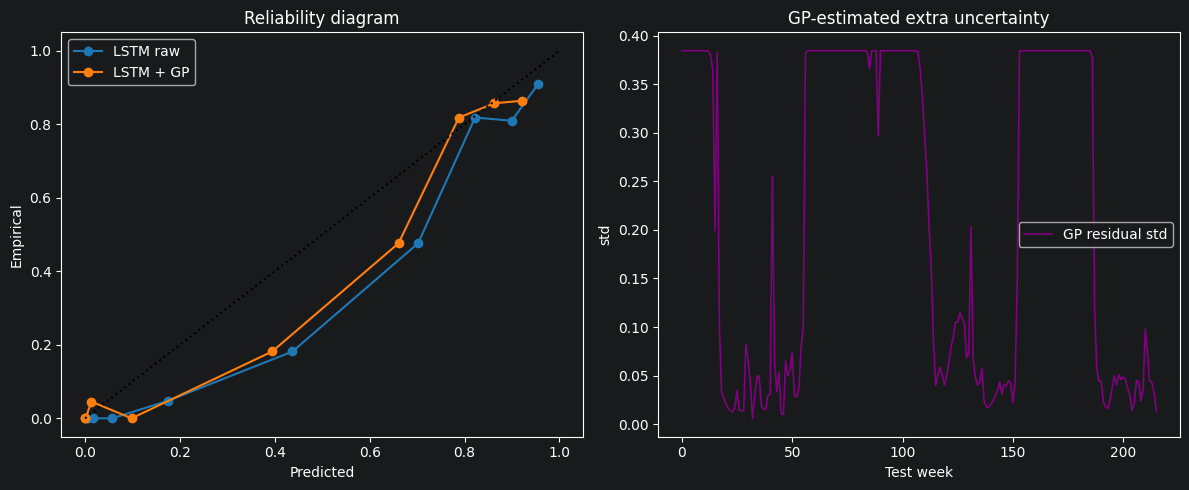

In [9]:
# --- Part 25: GP residual model ---
try:
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
except ImportError:
    !pip install scikit-learn -q
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

# Compact summary features per prediction point: last-timestep features
# (Could also use mean/std over window; keep it simple.)
def _gp_inputs(X_window):
    return X_window[:, -1, :]   # last timestep features (already scaled)

gp_X_val  = _gp_inputs(X_val)
gp_X_test = _gp_inputs(X_test)

# Baseline LSTM predictions on val and test (use existing trained_model)
lstm_p_val  = trained_model.predict(X_val,  verbose=0).flatten()
lstm_p_test = trained_model.predict(X_test, verbose=0).flatten()

# Residual target: y - p
resid_val  = y_val.flatten().astype(float)  - lstm_p_val
resid_test = y_test.flatten().astype(float) - lstm_p_test

# GP on validation residuals
# Use ARD: separate length-scale per feature for interpretability
n_feat = gp_X_val.shape[1]
kernel = (ConstantKernel(1.0, (1e-3, 1e3)) *
          RBF(length_scale=np.ones(n_feat), length_scale_bounds=(1e-2, 1e2)) +
          WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-5, 1.0)))

# GPs scale O(n^3): subsample if validation is large
MAX_GP_PTS = 500
if len(gp_X_val) > MAX_GP_PTS:
    sub = np.random.RandomState(0).choice(len(gp_X_val), MAX_GP_PTS, replace=False)
    gp_X_fit = gp_X_val[sub]; resid_fit = resid_val[sub]
else:
    gp_X_fit = gp_X_val; resid_fit = resid_val

print(f'Fitting GP on {len(gp_X_fit)} validation residuals...')
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True, n_restarts_optimizer=2)
gp.fit(gp_X_fit, resid_fit)
print(f'Learned kernel: {gp.kernel_}')

# Predict residual mean & std on test
resid_mean, resid_std = gp.predict(gp_X_test, return_std=True)
p_lstm_gp = np.clip(lstm_p_test + resid_mean, 0.0, 1.0)

gp_metrics = {
    'AUC':    roc_auc_score(y_eval_full, p_lstm_gp) if len(np.unique(y_eval_full)) > 1 else np.nan,
    'AUPRC':  average_precision_score(y_eval_full, p_lstm_gp),
    'Brier':  brier_score_loss(y_eval_full, p_lstm_gp),
    'F1@0.5': f1_score(y_eval_full, (p_lstm_gp >= 0.5).astype(int), zero_division=0),
}
print('\n--- LSTM + GP residual correction ---')
for k, v in gp_metrics.items():
    print(f'  {k}: {v:.4f}')

# Reliability diagram comparison
from sklearn.calibration import calibration_curve
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for label, probs, color in [('LSTM raw', lstm_p_test, 'tab:blue'),
                             ('LSTM + GP', p_lstm_gp,    'tab:orange')]:
    if len(np.unique(y_eval_full)) > 1:
        prob_true, prob_pred = calibration_curve(y_eval_full, probs, n_bins=10, strategy='quantile')
        ax[0].plot(prob_pred, prob_true, marker='o', label=label, color=color)
ax[0].plot([0,1],[0,1],'k:'); ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Empirical')
ax[0].set_title('Reliability diagram'); ax[0].legend()

# Uncertainty: GP std on test points
ax[1].plot(resid_std, color='purple', lw=1.2, label='GP residual std')
ax[1].set_xlabel('Test week'); ax[1].set_ylabel('std')
ax[1].set_title('GP-estimated extra uncertainty'); ax[1].legend()
plt.tight_layout(); plt.savefig('output_refactored/gp_uncertainty.png', dpi=200); plt.show()


## Part 26: Hybrid Ensemble (LSTM + ARIMA + Kalman, Performance-Weighted)

A linear ensemble of three forecasters where weights $w_i$ are recomputed every step from the **rolling 8-week negative-log-loss** of each component on the most recent observations:

$$w_i^{(t)} = \frac{\exp(-\eta\,\bar{\ell}_i^{(t)})}{\sum_j \exp(-\eta\,\bar{\ell}_j^{(t)})}$$

This is online exponentially-weighted averaging (Hedge). Components:

- **LSTM** — your trained baseline (`trained_model`)
- **ARIMA** — univariate ARIMA on log1p(kb), refit every step (or use fixed-order)
- **Kalman filter** — simple linear KF on log1p(kb) as a local-level + drift model


In [10]:
# --- Part 26: ARIMA forecaster with validation order tuning ---
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=Warning)

from scipy.stats import norm

def arima_rolling_prob(history_logkb, observed_logkb, order=(2, 1, 1)):
    forecasts, sigmas = [], []
    hist = list(history_logkb)
    for i, obs in enumerate(observed_logkb):
        try:
            m = ARIMA(hist, order=order).fit(method="statespace")
            f = m.get_forecast(steps=1)
            forecasts.append(float(f.predicted_mean[0]))
            sigmas.append(float(np.sqrt(f.var_pred_mean[0])))
        except Exception:
            forecasts.append(hist[-1])
            sigmas.append(float(np.std(np.diff(hist)) + 1e-3))
        hist.append(float(obs))
    return np.asarray(forecasts), np.asarray(sigmas)

log_thresh = np.log1p(BLOOM_THRESHOLD)
train_logkb = np.log1p(np.clip(train_df[TARGET_COL].astype(float).values, 0, None))
val_logkb = np.log1p(np.clip(validation_df[TARGET_COL].astype(float).values, 0, None))
test_logkb = np.log1p(np.clip(test_df[TARGET_COL].astype(float).values, 0, None))
y_val_arima = validation_df[TARGET_BINARY_COL].astype(int).values

candidate_orders = [(1, 0, 0), (1, 1, 0), (2, 1, 1), (3, 1, 1), (2, 0, 2)]
best_order, best_brier = None, np.inf
for order in candidate_orders:
    mean_v, sigma_v = arima_rolling_prob(train_logkb, val_logkb, order=order)
    prob_v = 1.0 - norm.cdf(log_thresh, loc=mean_v, scale=np.maximum(sigma_v, 1e-6))
    brier_v = brier_score_loss(y_val_arima[-len(prob_v):], prob_v)
    print(f"ARIMA{order}: val Brier={brier_v:.4f}")
    if brier_v < best_brier:
        best_brier = brier_v
        best_order = order

arima_hist = np.concatenate([train_logkb, val_logkb])
print(f"Running rolling ARIMA{best_order} on test...")
arima_mean, arima_sigma = arima_rolling_prob(arima_hist, test_logkb, order=best_order)
arima_bloom_prob_full = 1.0 - norm.cdf(log_thresh, loc=arima_mean, scale=np.maximum(arima_sigma, 1e-6))
alt_tuning_summary["arima"] = {"candidate_orders": candidate_orders, "best_order": best_order, "val_brier": float(best_brier)}


ARIMA(1, 0, 0): val Brier=0.1433
ARIMA(1, 1, 0): val Brier=0.1022
ARIMA(2, 1, 1): val Brier=0.1189
ARIMA(3, 1, 1): val Brier=0.1259
ARIMA(2, 0, 2): val Brier=0.1282
Running rolling ARIMA(1, 1, 0) on test...


In [11]:
# --- Part 26 (cont'd): validation-tuned linear Kalman filter on log1p(kb) ---
def linear_kf_rolling(obs_logkb, q_level=1e-2, q_drift=1e-4, r_obs=0.1):
    F = np.array([[1.0, 1.0], [0.0, 1.0]])
    H = np.array([[1.0, 0.0]])
    Q = np.diag([q_level, q_drift])
    R = np.array([[r_obs]])
    x = np.array([obs_logkb[0], 0.0])
    P = np.eye(2)
    preds, sigmas = [], []
    for z in obs_logkb:
        x = F @ x
        P = F @ P @ F.T + Q
        preds.append(float(x[0]))
        sigmas.append(float(np.sqrt(P[0, 0] + R[0, 0])))
        innov = z - H @ x
        S = H @ P @ H.T + R
        K = P @ H.T @ np.linalg.inv(S)
        x = x + (K @ innov).flatten()
        P = (np.eye(2) - K @ H) @ P
    return np.asarray(preds), np.asarray(sigmas)

kf_grid = [
    {"q_level": ql, "q_drift": qd, "r_obs": ro}
    for ql in [1e-3, 1e-2, 5e-2]
    for qd in [1e-5, 1e-4, 1e-3]
    for ro in [0.05, 0.1, 0.25]
]

best_kf, best_kf_brier = None, np.inf
full_train_val = np.concatenate([train_logkb, val_logkb])
for params in kf_grid:
    pred_all, sig_all = linear_kf_rolling(full_train_val, **params)
    pred_v = pred_all[len(train_logkb):]
    sig_v = sig_all[len(train_logkb):]
    prob_v = 1.0 - norm.cdf(log_thresh, loc=pred_v, scale=np.maximum(sig_v, 1e-6))
    brier_v = brier_score_loss(y_val_arima[-len(prob_v):], prob_v)
    if brier_v < best_kf_brier:
        best_kf_brier = brier_v
        best_kf = params

full_obs = np.concatenate([arima_hist, test_logkb])
kf_pred_all, kf_sig_all = linear_kf_rolling(full_obs, **best_kf)
kf_mean = kf_pred_all[len(arima_hist):]
kf_sigma = kf_sig_all[len(arima_hist):]
kf_bloom_prob_full = 1.0 - norm.cdf(log_thresh, loc=kf_mean, scale=np.maximum(kf_sigma, 1e-6))
alt_tuning_summary["kalman"] = {"grid_size": len(kf_grid), "best_params": best_kf, "val_brier": float(best_kf_brier)}
print(f"Best KF params: {best_kf}, val Brier={best_kf_brier:.4f}")


Best KF params: {'q_level': 0.05, 'q_drift': 0.001, 'r_obs': 0.05}, val Brier=0.1266



--- Hybrid ensemble (LSTM + ARIMA + KF) ---
Best Hedge params: {'roll_win': 12, 'eta': 0.5}, val Brier=0.0967
  AUC: 0.9658
  AUPRC: 0.9187
  Brier: 0.0649
  F1@0.5: 0.8873


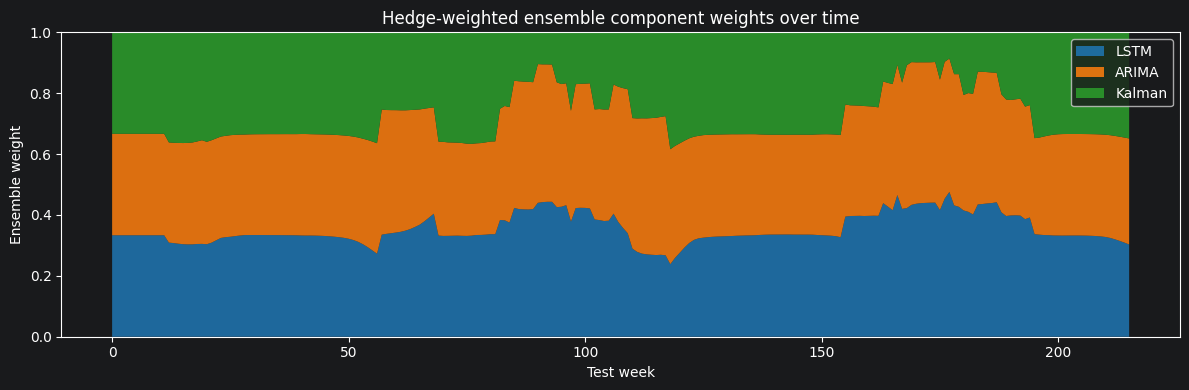

In [12]:
# --- Part 26 (cont'd): validation-tuned online performance-weighted blending ---
def _nll(p, y):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p))

def hedge_blend(component_probs, y_ref, roll_win=8, eta=2.0):
    n = len(y_ref)
    out = np.zeros(n)
    weights = np.zeros((n, len(component_probs)))
    comps = [np.asarray(p)[-n:] for p in component_probs]
    for t in range(n):
        if t < roll_win:
            w = np.ones(len(comps)) / len(comps)
        else:
            losses = np.array([
                _nll(p[t-roll_win:t], y_ref[t-roll_win:t]).mean()
                for p in comps
            ])
            s = np.exp(-eta * (losses - losses.min()))
            w = s / s.sum()
        weights[t] = w
        out[t] = float(sum(w_i * p_i[t] for w_i, p_i in zip(w, comps)))
    return out, weights

# Tune Hedge on validation using LSTM validation predictions and validation ARIMA/KF streams.
lstm_p_val = trained_model.predict(X_val, verbose=0).flatten()
arima_val_mean, arima_val_sigma = arima_rolling_prob(train_logkb, val_logkb, order=best_order)
arima_val_p = 1.0 - norm.cdf(log_thresh, loc=arima_val_mean, scale=np.maximum(arima_val_sigma, 1e-6))
kf_val_all, kf_val_sig_all = linear_kf_rolling(np.concatenate([train_logkb, val_logkb]), **best_kf)
kf_val_p = 1.0 - norm.cdf(log_thresh, loc=kf_val_all[len(train_logkb):], scale=np.maximum(kf_val_sig_all[len(train_logkb):], 1e-6))
y_val_blend = np.asarray(y_val).flatten().astype(int)
n_val = min(len(y_val_blend), len(lstm_p_val), len(arima_val_p), len(kf_val_p))

best_blend, best_blend_brier = None, np.inf
for roll_win in [4, 8, 12]:
    for eta in [0.5, 1.0, 2.0, 4.0]:
        p_val, _ = hedge_blend(
            [lstm_p_val[-n_val:], arima_val_p[-n_val:], kf_val_p[-n_val:]],
            y_val_blend[-n_val:],
            roll_win=roll_win,
            eta=eta,
        )
        brier_v = brier_score_loss(y_val_blend[-n_val:], p_val)
        if brier_v < best_blend_brier:
            best_blend_brier = brier_v
            best_blend = {"roll_win": roll_win, "eta": eta}

n_eval = len(y_eval_full)
lstm_p_full = lstm_p_test[-n_eval:]
arima_p = arima_bloom_prob_full[-n_eval:]
kf_p = kf_bloom_prob_full[-n_eval:]
blended, weights_history = hedge_blend(
    [lstm_p_full, arima_p, kf_p],
    y_eval_full,
    roll_win=best_blend["roll_win"],
    eta=best_blend["eta"],
)

hybrid_metrics = {
    "AUC": roc_auc_score(y_eval_full, blended) if len(np.unique(y_eval_full)) > 1 else np.nan,
    "AUPRC": average_precision_score(y_eval_full, blended),
    "Brier": brier_score_loss(y_eval_full, blended),
    "F1@0.5": f1_score(y_eval_full, (blended >= 0.5).astype(int), zero_division=0),
}
alt_tuning_summary["hedge_blend"] = {"grid": {"roll_win": [4, 8, 12], "eta": [0.5, 1.0, 2.0, 4.0]},
                                    "best_params": best_blend, "val_brier": float(best_blend_brier)}
print("\n--- Hybrid ensemble (LSTM + ARIMA + KF) ---")
print(f"Best Hedge params: {best_blend}, val Brier={best_blend_brier:.4f}")
for k, v in hybrid_metrics.items():
    print(f"  {k}: {v:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.stackplot(np.arange(n_eval), weights_history.T,
             labels=["LSTM", "ARIMA", "Kalman"],
             colors=["#1f77b4", "#ff7f0e", "#2ca02c"], alpha=0.85)
ax.set_ylim(0, 1)
ax.set_xlabel("Test week")
ax.set_ylabel("Ensemble weight")
ax.set_title("Hedge-weighted ensemble component weights over time")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_weights.png"), dpi=200)
plt.show()


## Persist all probability streams for notebook 07

In [13]:
# Collect per-model probability streams from this notebook's globals.
streams = {"lstm": lstm_p_test.astype(np.float32)}
if lstm_enkf_p_test is not None:
    streams["lstm_enkf_preprocessor"] = np.asarray(lstm_enkf_p_test).astype(np.float32).flatten()

stream_map = {
    "var": "var_prob_eval",
    "regime_switching": "p_regime_blend",
    "pinn": "pinn_bloom_pred",
    "lstm_gp": "p_lstm_gp",
    "hybrid_ensemble": "blended",
}

for key, varname in stream_map.items():
    if varname in dir():
        v = eval(varname)
        if isinstance(v, np.ndarray):
            streams[key] = v.astype(np.float32).flatten()
            print(f"  {key:24s} -> {varname} ({streams[key].shape})")
        else:
            print(f"  {key:24s} -> {varname} skipped (not ndarray)")
    else:
        print(f"  {key:24s} -> {varname} NOT FOUND")

streams["y_test"] = y_eval_full.astype(np.float32)
np.savez(ALT_MODEL_STREAMS_PATH, **streams)
write_json(ALT_MODEL_TUNING_SUMMARY_PATH, alt_tuning_summary)
print(f"\nWrote {ALT_MODEL_STREAMS_PATH}")
print(f"Wrote {ALT_MODEL_TUNING_SUMMARY_PATH}")
print(f"Keys: {list(streams.keys())}")


  var                      -> var_prob_eval ((216,))
  regime_switching         -> p_regime_blend ((216,))
  pinn                     -> pinn_bloom_pred ((216,))
  lstm_gp                  -> p_lstm_gp ((216,))
  hybrid_ensemble          -> blended ((216,))

Wrote output_refactored/intermediate\alt_model_streams.npz
Wrote output_refactored/intermediate\alt_model_tuning_summary.json
Keys: ['lstm', 'lstm_enkf_preprocessor', 'var', 'regime_switching', 'pinn', 'lstm_gp', 'hybrid_ensemble', 'y_test']
